# Spike deconvolution demo: OASIS vs CaImAn (CNMF.S)

This notebook is a presentation-friendly, "demo style" workflow to show:

1. What OASIS deconvolution is doing (denoising + spike inference) on a simple synthetic trace  
2. How to apply OASIS to a real CaImAn result (`caiman_results.hdf5`)  
3. How OASIS-inferred spikes compare to CaImAn-provided spikes (`cnmf.S`)

It is written to run even if the CaImAn file is not found (it will fall back to synthetic data).  
When the file exists, it will load the CNMF object and produce comparison plots.

**Your CaImAn file (as provided):**  
`/media/toor/SeagateClean/Mouse946/Round1/Linear/2026-02-05T16_54_25/caiman_final/caiman_results.hdf5`


In [1]:
# Notebook settings
%matplotlib inline
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)


## 1) Imports: OASIS (and CaImAn optional)

OASIS is commonly available either as part of CaImAn (`oasis.functions`) or as the standalone `oasis` package.

This cell tries a few import paths and raises a clear error if nothing is found.


In [2]:
def import_oasis_deconvolve():
    """Return (deconvolve, estimate_parameters) from whichever OASIS is available."""
    # Option 1: CaImAn's bundled oasis
    try:
        from oasis.functions import deconvolve, estimate_parameters
        return deconvolve, estimate_parameters
    except Exception:
        pass

    # Option 2: standalone oasis
    try:
        from oasis.oasis_methods import oasisAR1, oasisAR2
        # Provide a small wrapper so later code can stay uniform.
        def _deconvolve(y, penalty=1, g=None, s_min=0.0, b=None, optimize_b=True):
            y = np.asarray(y, dtype=float).ravel()
            if g is None:
                # crude default; later cells estimate g
                g_local = 0.95
            else:
                g_local = g if np.isscalar(g) else float(g[0])
            if penalty == 1:
                # no direct l1 wrapper in this old API, so we approximate with AR1 constrained
                c, s = oasisAR1(y - (np.median(y) if b is None else b), g=g_local, s_min=s_min)
            else:
                c, s = oasisAR1(y - (np.median(y) if b is None else b), g=g_local, s_min=s_min)
            b_out = np.median(y) if b is None else b
            lam = None
            return c + b_out, s, b_out, g_local, lam

        def _estimate_parameters(y, p=1):
            # minimal fallback
            y = np.asarray(y, dtype=float).ravel()
            b = np.percentile(y, 10)
            g = 0.95
            sn = np.std(y - np.convolve(y, np.ones(5)/5, mode="same"))
            return g, sn, b
        return _deconvolve, _estimate_parameters
    except Exception:
        pass

    raise ImportError(
        "Could not import OASIS.\n"
        "If you use CaImAn, you usually have it already: `from oasis.functions import deconvolve`.\n"
        "Otherwise try: `pip install oasis-deconv` or install CaImAn in this environment."
    )

deconvolve, estimate_parameters = import_oasis_deconvolve()
print("Loaded OASIS deconvolution functions:", deconvolve, estimate_parameters)


Loaded OASIS deconvolution functions: <function deconvolve at 0x7fcd7c0e7100> <function estimate_parameters at 0x7fcd7c0e7380>


/home/toor/miniconda3/envs/stability-preprocessing/lib/python3.11/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


## 2) Utility plotting helpers

We will use a consistent style for presentation figures.


In [3]:
def plot_deconv_panels(
    t,
    y,
    c,
    s,
    s_ref=None,
    c_ref=None,
    title=None,
    fs=12,
    zoom=None,
):
    """Multi-panel plot for fluorescence, denoised calcium, and spikes."""
    t = np.asarray(t)
    y = np.asarray(y).ravel()
    c = np.asarray(c).ravel()
    s = np.asarray(s).ravel()
    if s_ref is not None:
        s_ref = np.asarray(s_ref).ravel()
    if c_ref is not None:
        c_ref = np.asarray(c_ref).ravel()

    if zoom is None:
        idx = slice(None)
    else:
        t0, t1 = zoom
        idx = (t >= t0) & (t <= t1)

    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

    axes[0].plot(t[idx], y[idx], linewidth=1)
    axes[0].set_ylabel("F (input)", fontsize=fs)

    axes[1].plot(t[idx], c[idx], linewidth=1, label="OASIS c")
    if c_ref is not None:
        axes[1].plot(t[idx], c_ref[idx], linewidth=1, alpha=0.8, label="CaImAn C")
        axes[1].legend(frameon=False, fontsize=fs-2)
    axes[1].set_ylabel("Calcium c", fontsize=fs)

    axes[2].plot(t[idx], s[idx], linewidth=1, label="OASIS spikes")
    if s_ref is not None:
        axes[2].plot(t[idx], s_ref[idx], linewidth=1, alpha=0.8, label="CaImAn S")
        axes[2].legend(frameon=False, fontsize=fs-2)
    axes[2].set_ylabel("Spikes s", fontsize=fs)
    axes[2].set_xlabel("Time (frames)", fontsize=fs)

    if title:
        fig.suptitle(title, fontsize=fs+2)
    plt.tight_layout()
    return fig, axes


## 3) Synthetic trace demo (for explaining the algorithm)

This section creates a simple calcium trace from ground-truth spikes, adds noise, then runs OASIS.  
It is a clean way to show what "denoising" (c) and "deconvolution" (s) look like, before switching to real data.


In [5]:
def simulate_calcium_trace(T=2000, g=0.98, sn=0.3, b=2.0, rate=0.03, amp=1.0):
    """AR(1) calcium dynamics with sparse spikes."""
    s_true = (np.random.rand(T) < rate).astype(float) * amp
    c_true = np.zeros(T, dtype=float)
    for t in range(1, T):
        c_true[t] = g * c_true[t-1] + s_true[t]
    y = b + c_true + sn * np.random.randn(T)
    return y, c_true, s_true, dict(g=g, sn=sn, b=b)

T = 2500
y, c_true, s_true, params = simulate_calcium_trace(T=T, g=0.985, sn=0.35, b=2.0, rate=0.02, amp=1.2)
t = np.arange(T)

# Estimate parameters (optional, but shows "automatic" workflow)
g_hat, sn_hat = estimate_parameters(y, p=1)
b_hat = np.median(y)   # simple baseline estimate

c_hat, s_hat, b_out, g_out, lam = deconvolve(y, penalty=1)

print("True g/sn/b:", params)
print("Estimated g/sn/b (approx):", g_hat, sn_hat, b_hat)
print("OASIS returned b,g:", b_out, g_out)


True g/sn/b: {'g': 0.985, 'sn': 0.35, 'b': 2.0}
Estimated g/sn/b (approx): [0.99033263] 0.3401267129604434 3.6773743760426534
OASIS returned b,g: 2.5683172672216954 0.9705259737652012


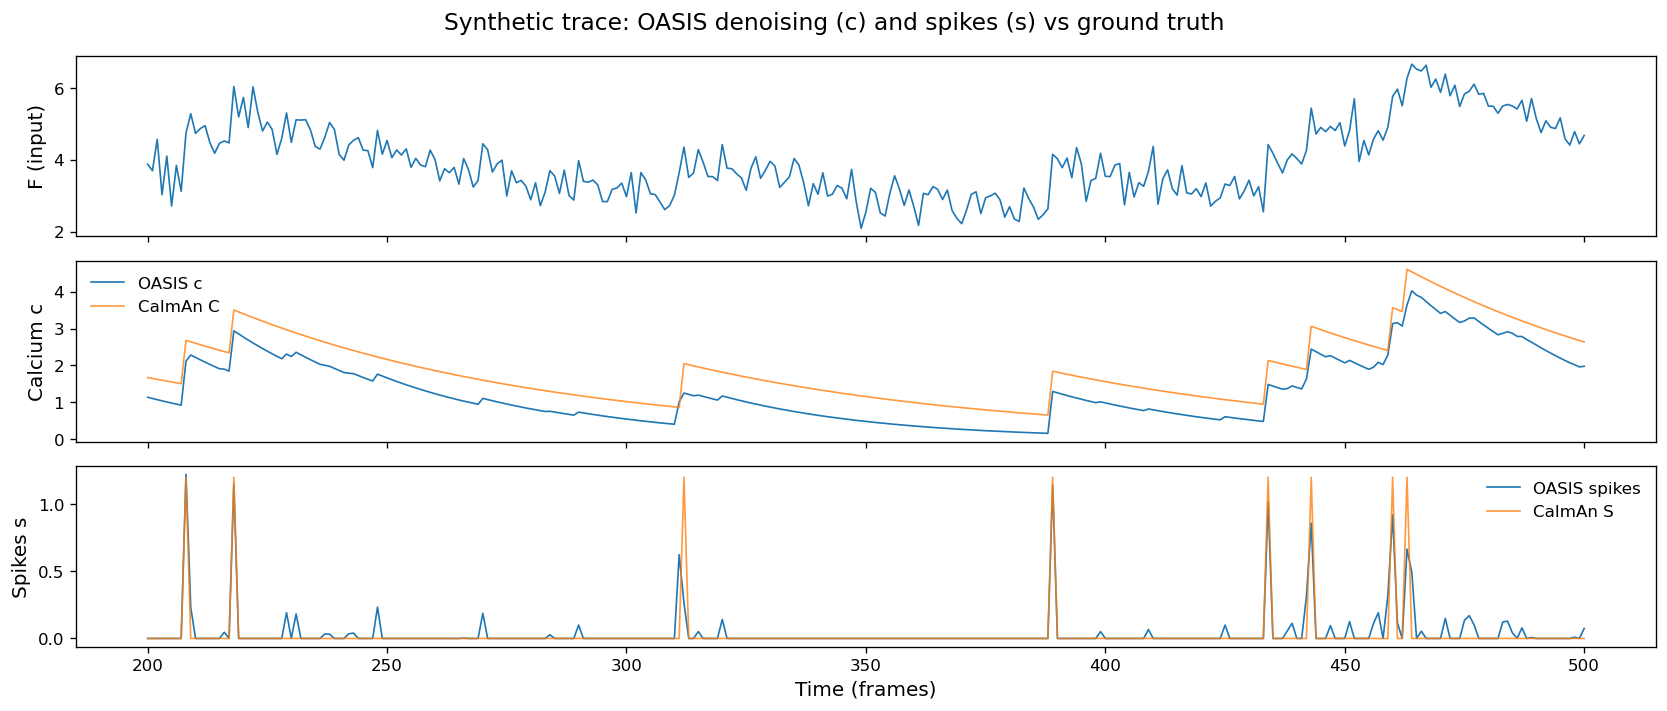

In [6]:
# Plot full trace and a zoom window
plot_deconv_panels(
    t,
    y,
    c_hat,
    s_hat,
    s_ref=s_true,
    c_ref=c_true,
    title="Synthetic trace: OASIS denoising (c) and spikes (s) vs ground truth",
    zoom=(200, 500),
)
plt.show()


### Save a figure for slides (optional)

This saves a PNG you can drop into a presentation.


In [7]:
FIG_DIR = Path("figures_oasis_demo")
FIG_DIR.mkdir(exist_ok=True)

fig, _ = plot_deconv_panels(
    t,
    y,
    c_hat,
    s_hat,
    s_ref=s_true,
    c_ref=c_true,
    title="Synthetic trace (zoom): OASIS vs ground truth",
    zoom=(200, 500),
)
out_path = FIG_DIR / "synthetic_oasis_vs_truth_zoom.png"
fig.savefig(out_path, bbox_inches="tight")
plt.close(fig)
print("Saved:", out_path.resolve())


Saved: /home/toor/Desktop/stability-preprocessing/figures_oasis_demo/synthetic_oasis_vs_truth_zoom.png


## 4) Load CaImAn results (CNMF object) from your directory

We try multiple loading strategies because CaImAn versions differ.

Expected outputs (if load succeeds):
- `C_caiman`: denoised calcium activity (components x time)
- `S_caiman`: inferred spikes from CaImAn (`cnmf.S`)
- `F_input`: a trace to feed into OASIS (ideally raw fluorescence or dF/F)

If raw fluorescence is not available from the saved object, we will fall back to `C_caiman` as the input trace, but note that this is not the same as deconvolving raw fluorescence.


In [8]:
CAIMAN_PATH = Path("/media/toor/SeagateClean/Mouse946/Round1/Linear/2026-02-05T16_54_25/caiman_final/caiman_results.hdf5")

def load_caiman_cnmf(path: Path):
    """Load a CaImAn CNMF object from a saved .hdf5 file, trying common APIs."""
    path = Path(path)
    if not path.exists():
        return None

    # Try the 'load_CNMF' helper
    try:
        from caiman.source_extraction.cnmf.cnmf import load_CNMF
        cnm = load_CNMF(str(path))
        return cnm
    except Exception:
        pass

    # Try caiman.utils.utils.load_object
    try:
        from caiman.utils.utils import load_object
        cnm = load_object(str(path))
        return cnm
    except Exception:
        pass

    # Try h5py fallback (limited)
    try:
        import h5py
        with h5py.File(path, "r") as f:
            keys = list(f.keys())
        raise RuntimeError(
            "Loaded the HDF5 container but could not reconstruct CNMF object.\n"
            f"Top-level keys: {keys}\n"
            "Try loading with CaImAn's `load_CNMF` in the same environment that produced the file."
        )
    except Exception as e:
        raise

def extract_traces_from_cnmf(cnm):
    """Extract C, S, and best available input fluorescence trace(s) from a CNMF object."""
    est = cnm.estimates

    C = getattr(est, "C", None)
    S = getattr(est, "S", None)

    # Candidate 'input' traces in decreasing preference order
    # Depending on pipeline, you may have:
    # - F_dff (components x time)
    # - F (components x time)
    # - YrA residual (components x time) to reconstruct Y = C + YrA
    F_input = None
    F_label = None

    if hasattr(est, "F_dff") and est.F_dff is not None:
        F_input = est.F_dff
        F_label = "F_dff"
    elif hasattr(est, "F") and est.F is not None:
        F_input = est.F
        F_label = "F"
    else:
        # Attempt reconstruction using C + YrA (common in CaImAn)
        YrA = getattr(est, "YrA", None)
        if (C is not None) and (YrA is not None):
            try:
                F_input = C + YrA
                F_label = "C + YrA (reconstructed)"  # closer to the movie signal per component
            except Exception:
                F_input = C
                F_label = "C (fallback)"
        else:
            F_input = C
            F_label = "C (fallback)"

    return dict(C=C, S=S, F_input=F_input, F_label=F_label)

cnm = None
if CAIMAN_PATH.exists():
    cnm = load_caiman_cnmf(CAIMAN_PATH)
    traces = extract_traces_from_cnmf(cnm)
    print("Loaded CaImAn CNMF from:", CAIMAN_PATH)
    print("Input trace source:", traces["F_label"])
    print("C shape:", None if traces["C"] is None else traces["C"].shape)
    print("S shape:", None if traces["S"] is None else traces["S"].shape)
else:
    print("CaImAn file not found at:", CAIMAN_PATH)
    print("This notebook will still run with synthetic data above.\n"
          "To run on your data, mount the drive and verify the path.")


Loaded CaImAn CNMF from: /media/toor/SeagateClean/Mouse946/Round1/Linear/2026-02-05T16_54_25/caiman_final/caiman_results.hdf5
Input trace source: F_dff
C shape: (522, 24008)
S shape: (522, 24008)


## 5) Pick an example component (cell) and run OASIS on its trace

You can change `cell_idx` to any component index you want for your presentation figure.


In [9]:
def choose_example_cell(traces, strategy="high_variance", top_k=20):
    """Pick a component index for a nice-looking demo."""
    F = traces["F_input"]
    if F is None:
        return 0
    F = np.asarray(F)
    if F.ndim != 2:
        return 0

    if strategy == "high_variance":
        var = np.var(F, axis=1)
        idxs = np.argsort(var)[::-1][:top_k]
        return int(idxs[0])
    return 0

if cnm is None:
    print("No CNMF loaded, skipping real-data OASIS section.")
else:
    cell_idx = choose_example_cell(traces, strategy="high_variance", top_k=50)
    print("Selected cell/component index:", cell_idx)


Selected cell/component index: 41


In [10]:
def run_oasis_on_trace(y, p=1, penalty=1):
    """Run OASIS and return (c, s, b, g, lam) plus parameter estimates."""
    y = np.asarray(y, dtype=float).ravel()

    # Estimate AR parameter and noise if possible
    try:
        g_hat, sn_hat, b_hat = estimate_parameters(y, p=p)
    except Exception:
        g_hat, sn_hat, b_hat = None, None, None

    # Deconvolve
    c, s, b, g, lam = deconvolve(y, penalty=penalty)
    return dict(c=c, s=s, b=b, g=g, lam=lam, g_hat=g_hat, sn_hat=sn_hat, b_hat=b_hat)

if cnm is None:
    pass
else:
    F = np.asarray(traces["F_input"])
    C_caiman = np.asarray(traces["C"]) if traces["C"] is not None else None
    S_caiman = np.asarray(traces["S"]) if traces["S"] is not None else None

    y_cell = F[cell_idx].ravel()
    t_cell = np.arange(y_cell.size)

    oasis_res_l1 = run_oasis_on_trace(y_cell, p=1, penalty=1)
    oasis_res_l0 = run_oasis_on_trace(y_cell, p=1, penalty=0)

    print("OASIS (l1) returned g:", oasis_res_l1["g"], "baseline b:", oasis_res_l1["b"])
    if oasis_res_l1["g_hat"] is not None:
        print("Estimated g_hat (approx):", oasis_res_l1["g_hat"])


OASIS (l1) returned g: 0.9687608426344503 baseline b: 0.0


### Plot comparison: input trace, CaImAn C/S, and OASIS c/s

For presentation, it is often helpful to show:
- the input fluorescence trace (what OASIS sees)
- CaImAn denoised calcium `C` (if available)
- OASIS denoised calcium `c`
- CaImAn spikes `S` vs OASIS spikes `s`

We plot a full view and a zoom view.


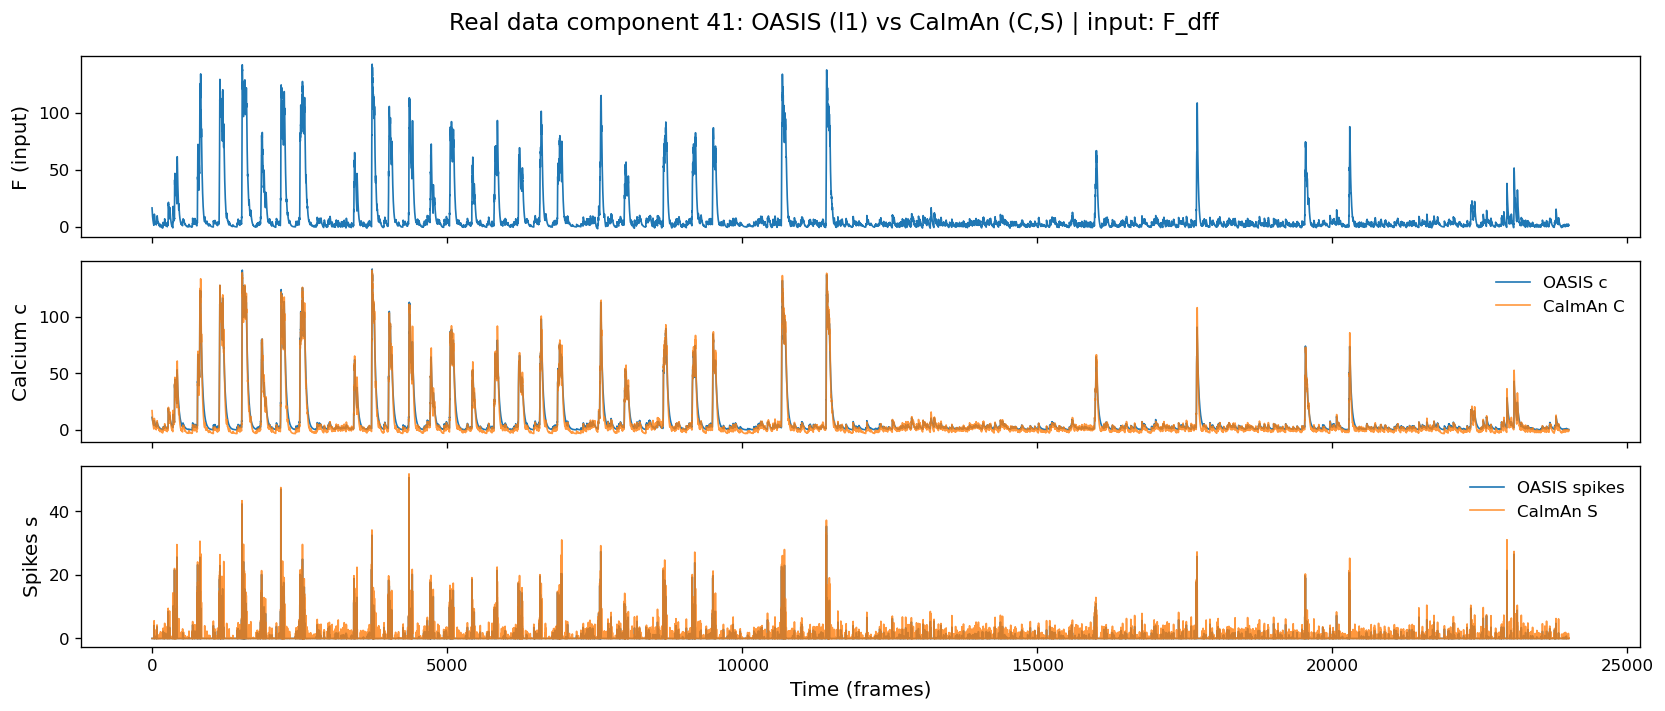

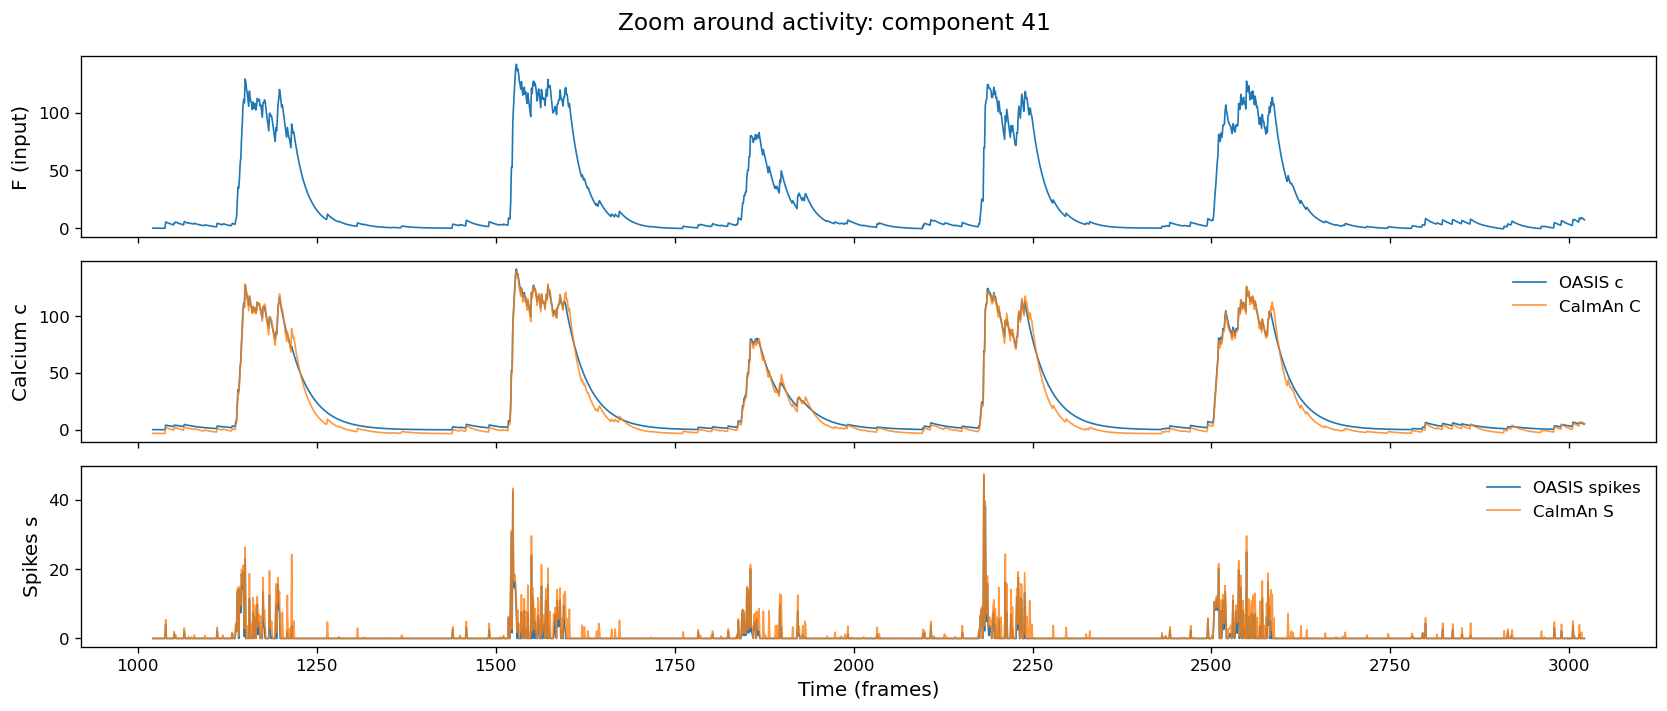

In [36]:
if cnm is None:
    pass
else:
    c_ref = C_caiman[cell_idx] if C_caiman is not None else None
    s_ref = S_caiman[cell_idx] if S_caiman is not None else None

    # Full view
    plot_deconv_panels(
        t_cell, y_cell,
        oasis_res_l1["c"], oasis_res_l1["s"],
        s_ref=s_ref, c_ref=c_ref,
        title=f"Real data component {cell_idx}: OASIS (l1) vs CaImAn (C,S) | input: {traces['F_label']}",
        zoom=None
    )
    plt.show()

    # Zoom window around the most active segment
    s_for_zoom = oasis_res_l1["s"]
    win = 1000
    center = int(np.argmax(np.convolve(np.abs(s_for_zoom), np.ones(win), mode="same")))
    t0 = max(center - win, 0)
    t1 = min(center + win, y_cell.size-1)

    plot_deconv_panels(
        t_cell, y_cell,
        oasis_res_l1["c"], oasis_res_l1["s"],
        s_ref=s_ref, c_ref=c_ref,
        title=f"Zoom around activity: component {cell_idx}",
        zoom=(t0, t1)
    )
    plt.show()


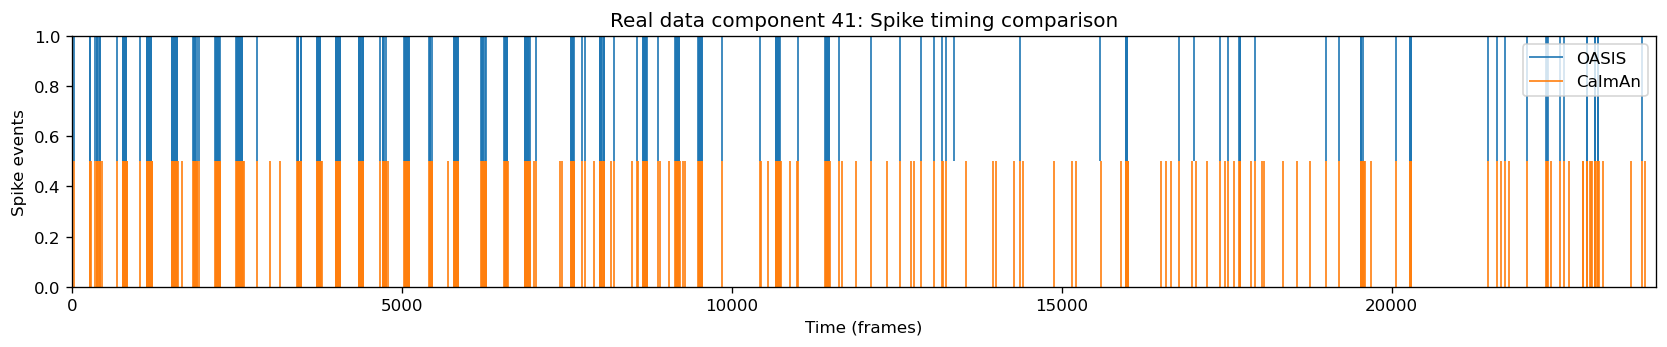

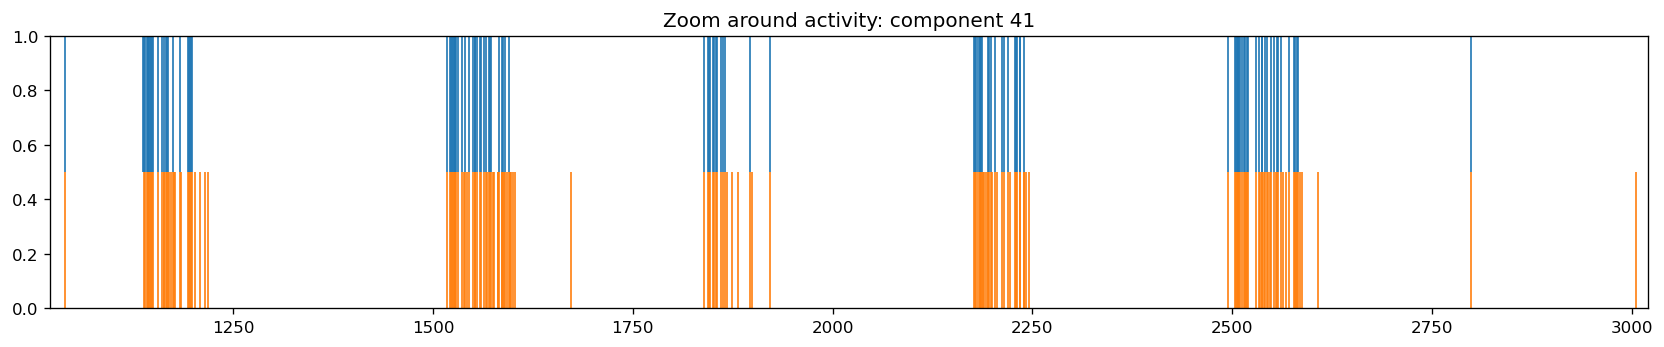

In [48]:
if cnm is not None:

    s_oasis = oasis_res_l1["s"]
    s_caiman = S_caiman[cell_idx] if S_caiman is not None else None

    # Thresholds
    thr_oasis = 4
    thr_caiman = 5

    spike_times_oasis = np.where(s_oasis > thr_oasis)[0]
    spike_times_caiman = (
        np.where(s_caiman > thr_caiman)[0]
        if s_caiman is not None else None
    )

    # ------------------------------------------------
    # FULL VIEW (same style as plot_deconv_panels)
    # ------------------------------------------------
    plt.figure(figsize=(14,3))

    plt.vlines(
        t_cell[spike_times_oasis],
        ymin=0.5, ymax=1,
        linewidth=1,
        color="tab:blue",
        label="OASIS"
    )

    if spike_times_caiman is not None:
        plt.vlines(
            t_cell[spike_times_caiman],
            ymin=0, ymax=0.5,
            linewidth=1,
            color="tab:orange",
            label="CaImAn"
        )

    plt.ylim(0,1)
    plt.xlim(t_cell[0], t_cell[-1])
    plt.xlabel("Time (frames)")
    plt.ylabel("Spike events")
    plt.title(
        f"Real data component {cell_idx}: Spike timing comparison"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------
    # ZOOM VIEW (using SAME t0, t1 window)
    # ------------------------------------------------
    plt.figure(figsize=(14,3))

    zoom_spikes_oasis = spike_times_oasis[
        (spike_times_oasis >= t0) & (spike_times_oasis <= t1)
    ]

    plt.vlines(
        t_cell[zoom_spikes_oasis],
        ymin=0.5, ymax=1,
        linewidth=1,
        color="tab:blue"
    )

    if spike_times_caiman is not None:
        zoom_spikes_caiman = spike_times_caiman[
            (spike_times_caiman >= t0) & (spike_times_caiman <= t1)
        ]
        plt.vlines(
            t_cell[zoom_spikes_caiman],
            ymin=0, ymax=0.5,
            linewidth=1,
            color="tab:orange"
        )

    plt.ylim(0,1)
    plt.xlim(t_cell[t0], t_cell[t1])
    plt.title(
        f"Zoom around activity: component {cell_idx}"
    )
    plt.tight_layout()
    plt.show()


## 6) Side-by-side: OASIS penalties (l1 vs l0)

This makes it easy to explain that:
- l1 gives a convex objective (often more stable)
- l0 is non-convex (often sparser, but can be sensitive)

For your claim of "high confidence", l1 is usually the safer story to tell, while l0 can be shown as an alternative.


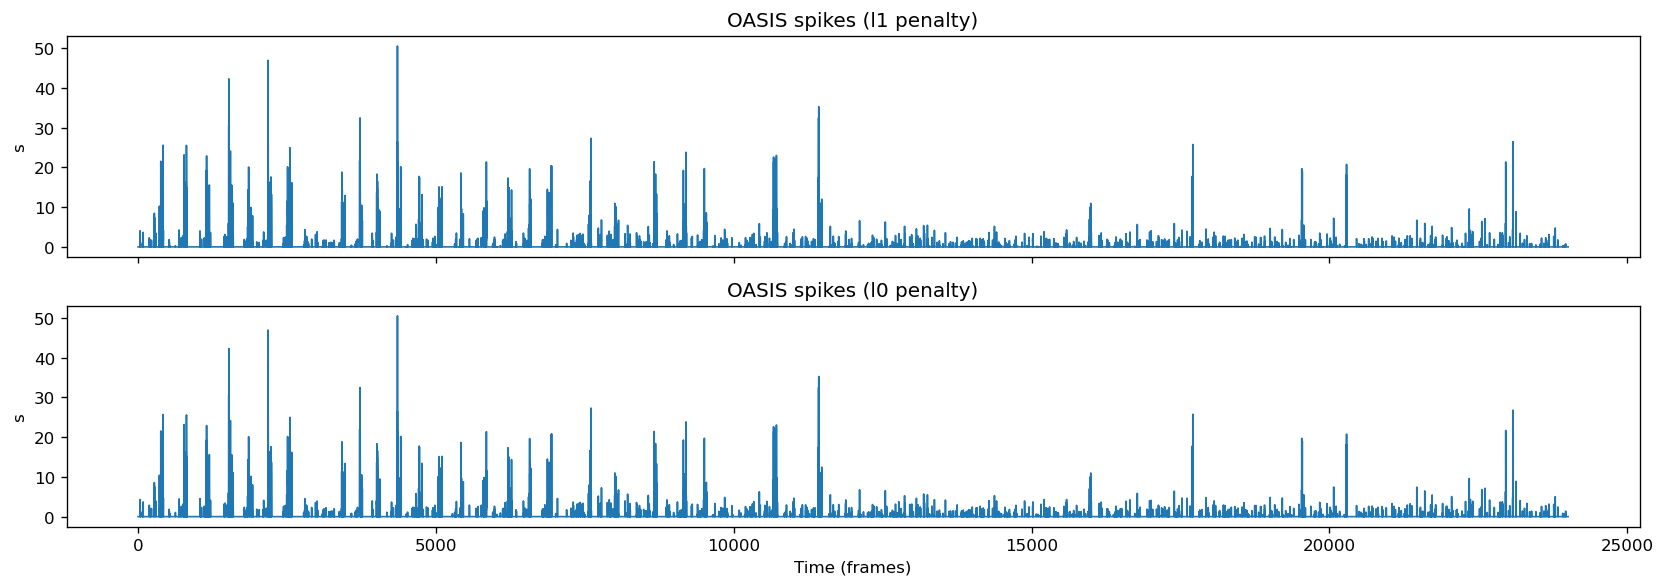

In [39]:
if cnm is None:
    pass
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
   

    axes[0].plot(t_cell, oasis_res_l1["s"], linewidth=1)
    axes[0].set_title("OASIS spikes (l1 penalty)")
    axes[0].set_ylabel("s")

    axes[1].plot(t_cell, oasis_res_l0["s"], linewidth=1)
    axes[1].set_title("OASIS spikes (l0 penalty)")
    axes[1].set_ylabel("s")
    axes[1].set_xlabel("Time (frames)")

    plt.tight_layout()
    plt.show()


## 7) Save figures for slides

This cell exports a few key figures into `figures_oasis_demo/`.


In [13]:
if cnm is None:
    print("No CNMF loaded, nothing to export for real data.")
else:
    # Ensure dir exists
    FIG_DIR.mkdir(exist_ok=True)

    c_ref = C_caiman[cell_idx] if C_caiman is not None else None
    s_ref = S_caiman[cell_idx] if S_caiman is not None else None

    fig, _ = plot_deconv_panels(
        t_cell, y_cell,
        oasis_res_l1["c"], oasis_res_l1["s"],
        s_ref=s_ref, c_ref=c_ref,
        title=f"Real data: component {cell_idx} (full)",
        zoom=None
    )
    p1 = FIG_DIR / f"real_component_{cell_idx}_full.png"
    fig.savefig(p1, bbox_inches="tight")
    plt.close(fig)

    fig, _ = plot_deconv_panels(
        t_cell, y_cell,
        oasis_res_l1["c"], oasis_res_l1["s"],
        s_ref=s_ref, c_ref=c_ref,
        title=f"Real data: component {cell_idx} (zoom)",
        zoom=(t0, t1)
    )
    p2 = FIG_DIR / f"real_component_{cell_idx}_zoom.png"
    fig.savefig(p2, bbox_inches="tight")
    plt.close(fig)

    # Penalty comparison
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].plot(t_cell, oasis_res_l1["s"], linewidth=1)
    axes[0].set_title("OASIS spikes (l1)")
    axes[0].set_ylabel("s")
    axes[1].plot(t_cell, oasis_res_l0["s"], linewidth=1)
    axes[1].set_title("OASIS spikes (l0)")
    axes[1].set_ylabel("s")
    axes[1].set_xlabel("Time (frames)")
    plt.tight_layout()
    p3 = FIG_DIR / f"real_component_{cell_idx}_l1_vs_l0.png"
    fig.savefig(p3, bbox_inches="tight")
    plt.close(fig)

    print("Saved figures:")
    for p in [p1, p2, p3]:
        print(" -", p.resolve())


Saved figures:
 - /home/toor/Desktop/stability-preprocessing/figures_oasis_demo/real_component_41_full.png
 - /home/toor/Desktop/stability-preprocessing/figures_oasis_demo/real_component_41_zoom.png
 - /home/toor/Desktop/stability-preprocessing/figures_oasis_demo/real_component_41_l1_vs_l0.png


## PLotting Spikes as lines

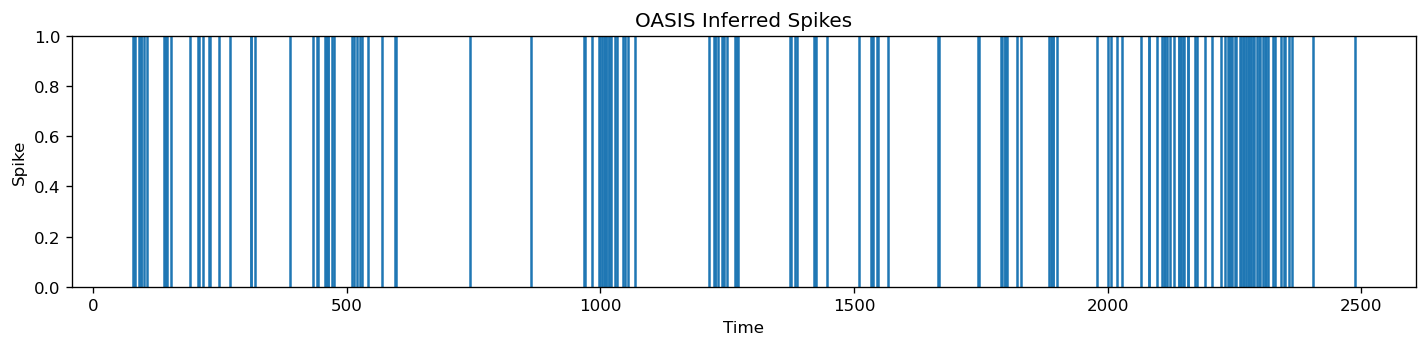

In [26]:
# threshold to remove tiny values
spike_threshold = np.percentile(s_hat[s_hat > 0], 50) if np.any(s_hat > 0) else 0
spike_times = np.where(s_hat > spike_threshold)[0]

plt.figure(figsize=(12,3))
plt.vlines(spike_times, ymin=0, ymax=1, linewidth=1.5)
plt.ylim(0, 1)
plt.title("OASIS Inferred Spikes")
plt.xlabel("Time")
plt.ylabel("Spike")
plt.tight_layout()
plt.show()


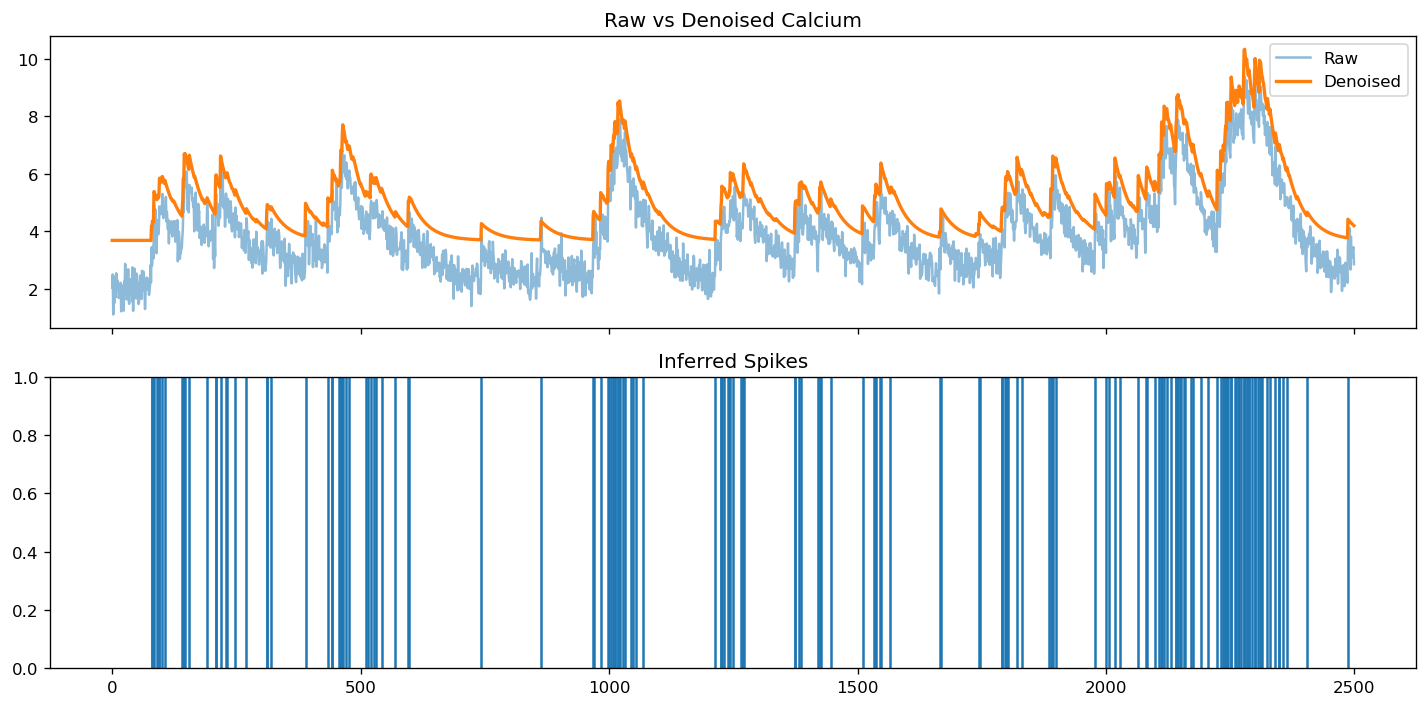

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# Top: Calcium traces
ax[0].plot(y, label="Raw", alpha=0.5)
ax[0].plot(c_hat + b_hat, label="Denoised", linewidth=2)
ax[0].legend()
ax[0].set_title("Raw vs Denoised Calcium")

# Bottom: Spikes as vertical lines
ax[1].vlines(spike_times, ymin=0, ymax=1, linewidth=1.5)
ax[1].set_ylim(0,1)
ax[1].set_title("Inferred Spikes")

plt.tight_layout()
plt.show()


In [ ]:
def plot_deconv_panels(
    t, y, c_oasis, s_oasis,
    s_ref=None, c_ref=None,
    title="",
    zoom=None,
    spike_lines=True   # ← add this
):
# ----------------------
# Spike panel
# ----------------------
ax_spike = axes[2]

if spike_lines:

    # OASIS spikes
    spike_thr = 0.01
    spike_times = np.where(s_oasis > spike_thr)[0]
    ax_spike.vlines(t[spike_times], ymin=0.5, ymax=1, linewidth=1.2, label="OASIS")

    # CaImAn spikes
    if s_ref is not None:
        spike_thr_ref = 0.01
        spike_times_ref = np.where(s_ref > spike_thr_ref)[0]
        ax_spike.vlines(t[spike_times_ref], ymin=0, ymax=0.5,
                        color="red", linewidth=1.2, label="CaImAn")

    ax_spike.set_ylim(0,1)
    ax_spike.set_ylabel("Spikes")
    ax_spike.legend()

else:
    # fallback continuous plotting
    ax_spike.plot(t, s_oasis, label="OASIS")
    if s_ref is not None:
        ax_spike.plot(t, s_ref, label="CaImAn", alpha=0.7)
    ax_spike.legend()


SyntaxError: incomplete input (2576005263.py, line 7)

### Denoising

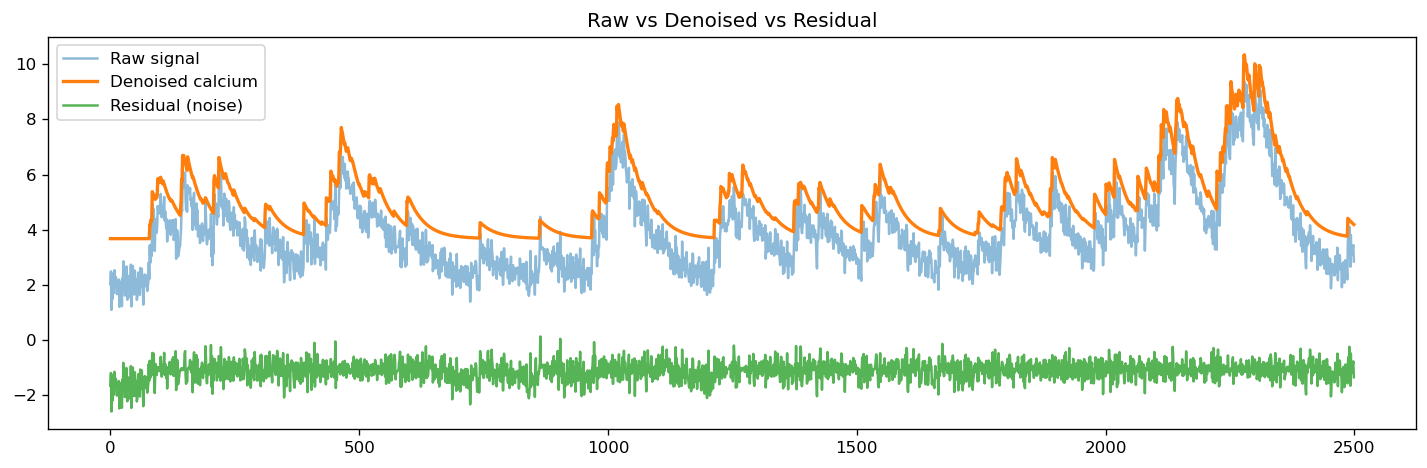

In [14]:
# residual = raw - (denoised calcium + baseline)
residual = y - (c_hat + b_hat)

plt.figure(figsize=(12,4))
plt.plot(t, y, label='Raw signal', alpha=0.5)
plt.plot(t, c_hat + b_hat, label='Denoised calcium', linewidth=2)
plt.plot(t, residual, label='Residual (noise)', alpha=0.8)
plt.legend()
plt.title("Raw vs Denoised vs Residual")
plt.tight_layout()
plt.show()


In [ ]:
# If deconvolution works well, residual variance is much smaller.

raw_var = np.var(y)
res_var = np.var(residual)

print("Raw variance:", raw_var)
print("Residual variance:", res_var)
print("Variance reduction:", 1 - res_var/raw_var)


Raw variance: 1.9073593987243374
Residual variance: 0.11568984151083486
Variance reduction: 0.9393455467342917


In [16]:
print("Estimated noise (sn_hat):", sn_hat)
print("Residual std:", np.std(residual))


Estimated noise (sn_hat): 0.3401267129604434
Residual std: 0.3401320942087572


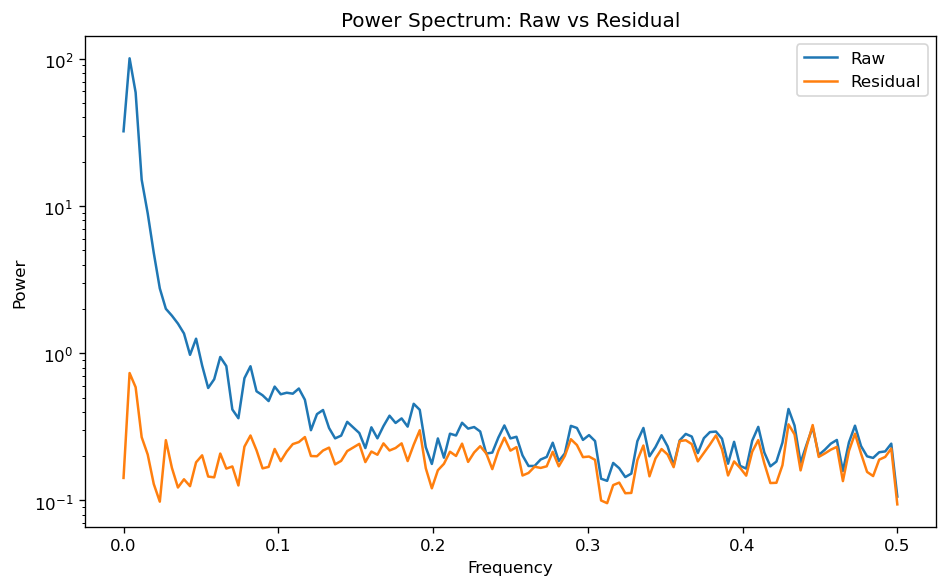

In [17]:
from scipy.signal import welch

f_raw, Pxx_raw = welch(y, fs=1)
f_res, Pxx_res = welch(residual, fs=1)

plt.figure(figsize=(8,5))
plt.semilogy(f_raw, Pxx_raw, label='Raw')
plt.semilogy(f_res, Pxx_res, label='Residual')
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.legend()
plt.title("Power Spectrum: Raw vs Residual")
plt.tight_layout()
plt.show()


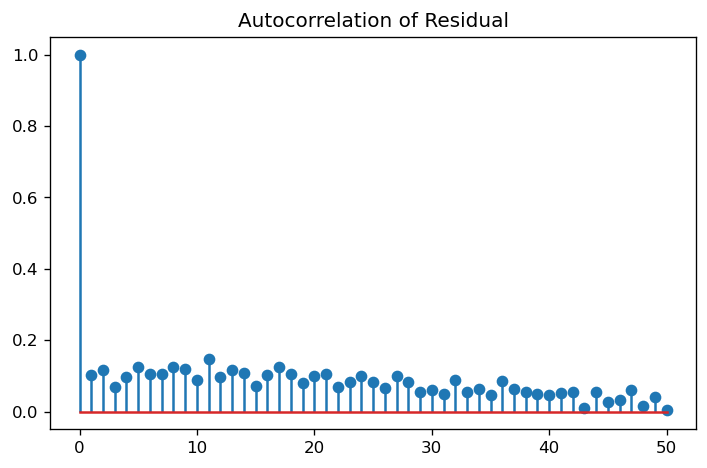

In [ ]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(residual, nlags=50)

plt.figure(figsize=(6,4))
plt.stem(acf_vals)
plt.title("Autocorrelation of Residual")
plt.tight_layout()
plt.show()


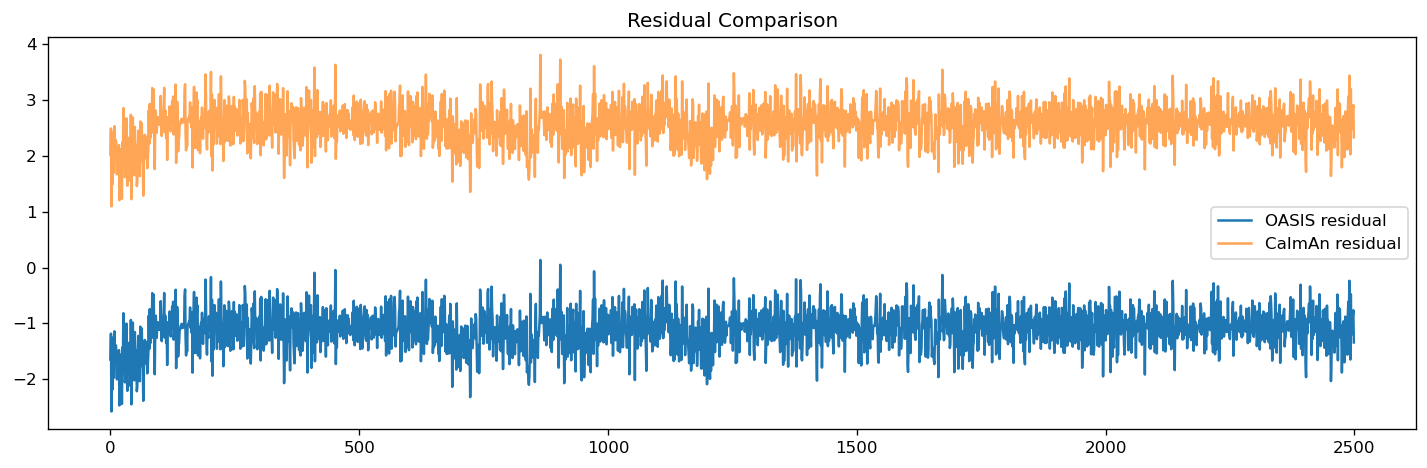

In [23]:
caiman_residual = y - c_hat

plt.figure(figsize=(12,4))
plt.plot(residual, label="OASIS residual")
plt.plot(caiman_residual, label="CaImAn residual", alpha=0.7)
plt.legend()
plt.title("Residual Comparison")
plt.tight_layout()
plt.show()
